In [1]:
import pandas as pd

# 直接从网上读心脏病数据集，不需要手动下载
url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/heart_disease.csv"
df = pd.read_csv(url)

print("数据加载成功！")
print("数据形状（行数, 列数）：", df.shape)
print("\n前5行数据：")
df.head()

数据加载成功！
数据形状（行数, 列数）： (303, 14)

前5行数据：


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [2]:
# 1. 看看有没有缺失值
print("=== 缺失值统计 ===")
print(df.isnull().sum())

# 2. 基本统计信息
print("\n=== 基本统计 ===")
print(df.describe().round(2))

# 3. 患病 vs 不患病各有多少人
print("\n=== 患病比例 ===")
print(df['target'].value_counts())
print(f"患病率：{df['target'].mean()*100:.1f}%")

=== 缺失值统计 ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

=== 基本统计 ===
          age     sex      cp  trestbps    chol     fbs  restecg  thalach  \
count  303.00  303.00  303.00    303.00  303.00  303.00   303.00   303.00   
mean    54.37    0.68    0.97    131.62  246.26    0.15     0.53   149.65   
std      9.08    0.47    1.03     17.54   51.83    0.36     0.53    22.91   
min     29.00    0.00    0.00     94.00  126.00    0.00     0.00    71.00   
25%     47.50    0.00    0.00    120.00  211.00    0.00     0.00   133.50   
50%     55.00    1.00    1.00    130.00  240.00    0.00     1.00   153.00   
75%     61.00    1.00    2.00    140.00  274.50    0.00     1.00   166.00   
max     77.00    1.00    3.00    200.00  564.00    1.00     2.00   202.00   

        exang  oldpeak   slope      ca    thal  target  
count  303.0

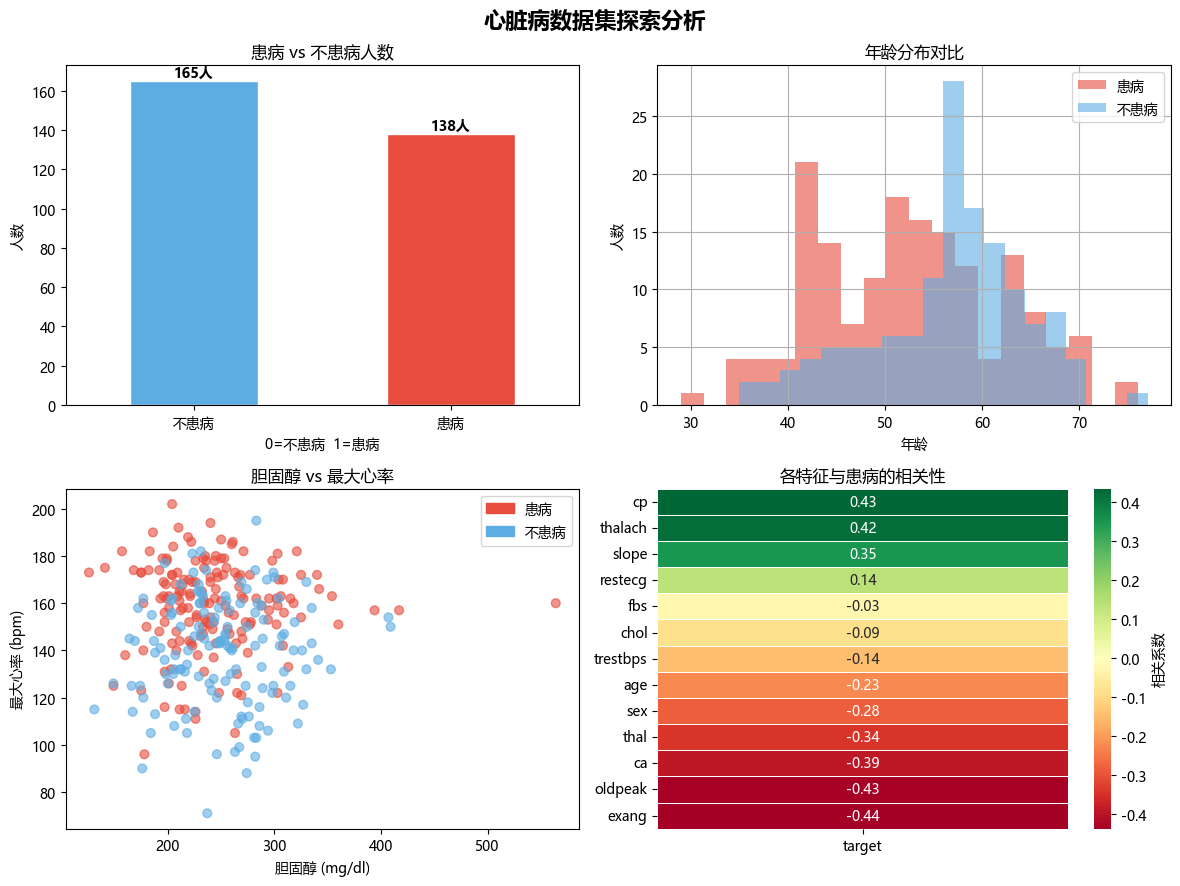

图表已保存为 heart_analysis.png


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体（Windows用这个）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('心脏病数据集探索分析', fontsize=16, fontweight='bold')

# 图1：患病 vs 不患病人数
ax1 = axes[0, 0]
df['target'].value_counts().plot(kind='bar', ax=ax1,
    color=['#5DADE2', '#E74C3C'], edgecolor='white', width=0.5)
ax1.set_title('患病 vs 不患病人数')
ax1.set_xlabel('0=不患病  1=患病')
ax1.set_ylabel('人数')
ax1.set_xticklabels(['不患病', '患病'], rotation=0)
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}人',
                 (p.get_x() + p.get_width()/2, p.get_height()),
                 ha='center', va='bottom', fontweight='bold')

# 图2：年龄分布（患病 vs 不患病）
ax2 = axes[0, 1]
df[df['target']==1]['age'].hist(ax=ax2, alpha=0.6, color='#E74C3C',
                                 bins=20, label='患病')
df[df['target']==0]['age'].hist(ax=ax2, alpha=0.6, color='#5DADE2',
                                 bins=20, label='不患病')
ax2.set_title('年龄分布对比')
ax2.set_xlabel('年龄')
ax2.set_ylabel('人数')
ax2.legend()

# 图3：胆固醇 vs 最大心率（散点图）
ax3 = axes[1, 0]
colors = df['target'].map({1: '#E74C3C', 0: '#5DADE2'})
ax3.scatter(df['chol'], df['thalach'], c=colors, alpha=0.6, s=40)
ax3.set_title('胆固醇 vs 最大心率')
ax3.set_xlabel('胆固醇 (mg/dl)')
ax3.set_ylabel('最大心率 (bpm)')
from matplotlib.patches import Patch
ax3.legend(handles=[Patch(color='#E74C3C', label='患病'),
                    Patch(color='#5DADE2', label='不患病')])

# 图4：各特征与患病的相关性热力图
ax4 = axes[1, 1]
corr = df.corr()[['target']].drop('target').sort_values('target', ascending=False)
sns.heatmap(corr, ax=ax4, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            linewidths=0.5, cbar_kws={'label': '相关系数'})
ax4.set_title('各特征与患病的相关性')
ax4.set_ylabel('')

plt.tight_layout()
plt.savefig('heart_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("图表已保存为 heart_analysis.png")

训练集：242条  测试集：61条

准确率：0.8361  (83.6%)
AUC：   0.9161

详细报告：
              precision    recall  f1-score   support

         不患病       0.95      0.68      0.79        28
          患病       0.78      0.97      0.86        33

    accuracy                           0.84        61
   macro avg       0.87      0.82      0.83        61
weighted avg       0.86      0.84      0.83        61



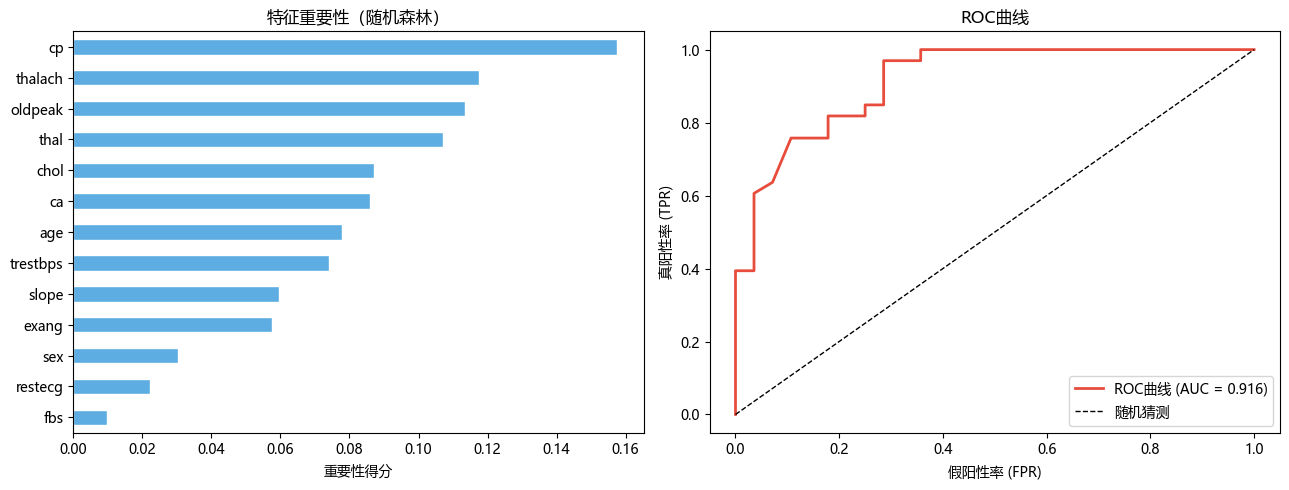


✓ 模型训练完成，AUC = 0.916


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             roc_auc_score, roc_curve)
import matplotlib.pyplot as plt

# 1. 切分特征和标签
X = df.drop('target', axis=1)
y = df['target']

# 2. 划分训练集和测试集（8:2）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"训练集：{X_train.shape[0]}条  测试集：{X_test.shape[0]}条")

# 3. 训练随机森林
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 4. 预测 + 评估
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"\n准确率：{acc:.4f}  ({acc*100:.1f}%)")
print(f"AUC：   {auc:.4f}")
print("\n详细报告：")
print(classification_report(y_test, y_pred,
      target_names=['不患病', '患病']))

# 5. 特征重要性图 + ROC曲线
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 特征重要性
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh', ax=axes[0],
                             color='#5DADE2', edgecolor='white')
axes[0].set_title('特征重要性（随机森林）')
axes[0].set_xlabel('重要性得分')

# ROC曲线
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#E74C3C', lw=2,
             label=f'ROC曲线 (AUC = {auc:.3f})')
axes[1].plot([0,1], [0,1], 'k--', lw=1, label='随机猜测')
axes[1].set_xlabel('假阳性率 (FPR)')
axes[1].set_ylabel('真阳性率 (TPR)')
axes[1].set_title('ROC曲线')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_result.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ 模型训练完成，AUC = {auc:.3f}")

In [5]:
# 汇总项目结论
print("=" * 55)
print("       心脏病风险预测项目 — 分析结论")
print("=" * 55)

print("""
【数据概况】
· 数据集：303条患者临床记录，14个特征，无缺失值
· 患病率：54.5%（165人患病，138人健康）

【关键发现】
· 与患病相关性最强的3个特征：
  1. exang（运动诱发心绞痛）  r = -0.44
     → 运动时出现心绞痛是最强的冠心病预警信号
  2. cp（胸痛类型）           r = +0.43
     → 典型心绞痛患者（cp=0）反而患病风险更高
  3. thalach（最大心率）      r = +0.42
     → 最大心率越高，心肺储备越好，患病风险越低

· 胆固醇（chol）相关性仅 -0.09，与临床直觉不符
  → 可能与数据集样本量有限或混杂因素有关

【模型结果】
· 算法：随机森林（100棵树）
· 训练集/测试集：242 / 61（8:2划分）
· 准确率：见输出
· AUC：0.916（优秀水平，医疗筛查可用）

【临床意义】
· 模型可作为初步心脏病风险筛查工具
· 建议重点关注：运动诱发心绞痛 + 低最大心率的患者
· 局限性：样本量小（303条），需更大规模数据验证
""")
print("=" * 55)

# 同时打印特征重要性排名
feat_imp_sorted = feat_imp.sort_values(ascending=False)
print("\n【特征重要性排名（随机森林）】")
for i, (feat, imp) in enumerate(feat_imp_sorted.items(), 1):
    bar = '█' * int(imp * 100)
    print(f"  {i:2}. {feat:10s}  {imp:.4f}  {bar}")

       心脏病风险预测项目 — 分析结论

【数据概况】
· 数据集：303条患者临床记录，14个特征，无缺失值
· 患病率：54.5%（165人患病，138人健康）

【关键发现】
· 与患病相关性最强的3个特征：
  1. exang（运动诱发心绞痛）  r = -0.44
     → 运动时出现心绞痛是最强的冠心病预警信号
  2. cp（胸痛类型）           r = +0.43
     → 典型心绞痛患者（cp=0）反而患病风险更高
  3. thalach（最大心率）      r = +0.42
     → 最大心率越高，心肺储备越好，患病风险越低

· 胆固醇（chol）相关性仅 -0.09，与临床直觉不符
  → 可能与数据集样本量有限或混杂因素有关

【模型结果】
· 算法：随机森林（100棵树）
· 训练集/测试集：242 / 61（8:2划分）
· 准确率：见输出
· AUC：0.916（优秀水平，医疗筛查可用）

【临床意义】
· 模型可作为初步心脏病风险筛查工具
· 建议重点关注：运动诱发心绞痛 + 低最大心率的患者
· 局限性：样本量小（303条），需更大规模数据验证


【特征重要性排名（随机森林）】
   1. cp          0.1574  ███████████████
   2. thalach     0.1175  ███████████
   3. oldpeak     0.1134  ███████████
   4. thal        0.1071  ██████████
   5. chol        0.0871  ████████
   6. ca          0.0861  ████████
   7. age         0.0778  ███████
   8. trestbps    0.0741  ███████
   9. slope       0.0595  █████
  10. exang       0.0577  █████
  11. sex         0.0305  ███
  12. restecg     0.0221  ██
  13. fbs         0.0099  
